# GHG Emission Note: Calculate Total CO₂e

This notebook calculates total greenhouse gas (GHG) emissions in CO₂ equivalent (CO₂e) from emission factors (EFs) of three major gases:

- **CO₂ (Carbon dioxide)**
- **CH₄ (Methane)**
- **N₂O (Nitrous oxide)**

Only these three are considered **direct greenhouse gases** in standard GHG inventories.

# Steps:
1. Input emission factors (EF) in grams per unit of fuel or activity.
2. Use IPCC AR6 100-year Global Warming Potentials (GWP):
   - CH₄ → 29.8
   - N₂O → 273
   - CO₂ → 1 (baseline)

3. Apply the formula
  Total CO₂e = CO₂ + (CH₄ × GWP_CH₄) + (N₂O × GWP_N₂O)


# DATA:
  From GREET 2024 per mmbtu diesel fuel for framing tractor:
  EF_CH4=0.630
  EF_N2O=0.920
  EF_CO2=77,754

  Diesel for non-road engines heating value:
  128,450 BTU/gal
  3.78541 liters in a gallon
  128,450 BTU/gallon = 33,933 BTU/liter

  1000000btu/ (33933btu/liter)=29.47 liter

  per liter diesel fuel for framing tractor:
  EF_CH4=0.630/29.47
  EF_N2O=0.920/29.47
  EF_CO2=77,754/29.47

  total CO₂e for per liter of diesel fuel:
  Total CO₂e = 77,754/29.47 + (0.630/29.47 × 29.8) + (0.920/29.47 × 273) = 2647g
  =2.647kg/liter

  GHG-100 FOR conventional diesel from crude oil for us refineries
  = 0.55kg/liter

  2.647+0.55 = 3.197kg/liter

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = []  # optional custom font directory (none bundled in this repo)
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

[]


   State  Diesel (L/1000kg)  Electricity (kWh/1000kg)  Current Rate  \
0     AL               27.8                     341.2          -7.8   
1     AZ               78.8                     907.3         -11.3   
2     AR               58.5                     404.1         -12.6   
3     CA               78.2                     473.2          -4.6   
4     FL               90.8                     381.6          -5.7   
5     GA               46.5                     610.8          -9.1   
6     KS               83.5                     966.4          -7.3   
7     LA               67.9                     431.3         -12.6   
8     MS               63.8                     383.7         -12.5   
9     MO               77.3                     614.8          -8.3   
10    NC               62.2                     819.8         -10.0   
11    NM              164.8                    1715.6          -7.6   
12    OK               94.2                    1000.9          -4.0   
13    

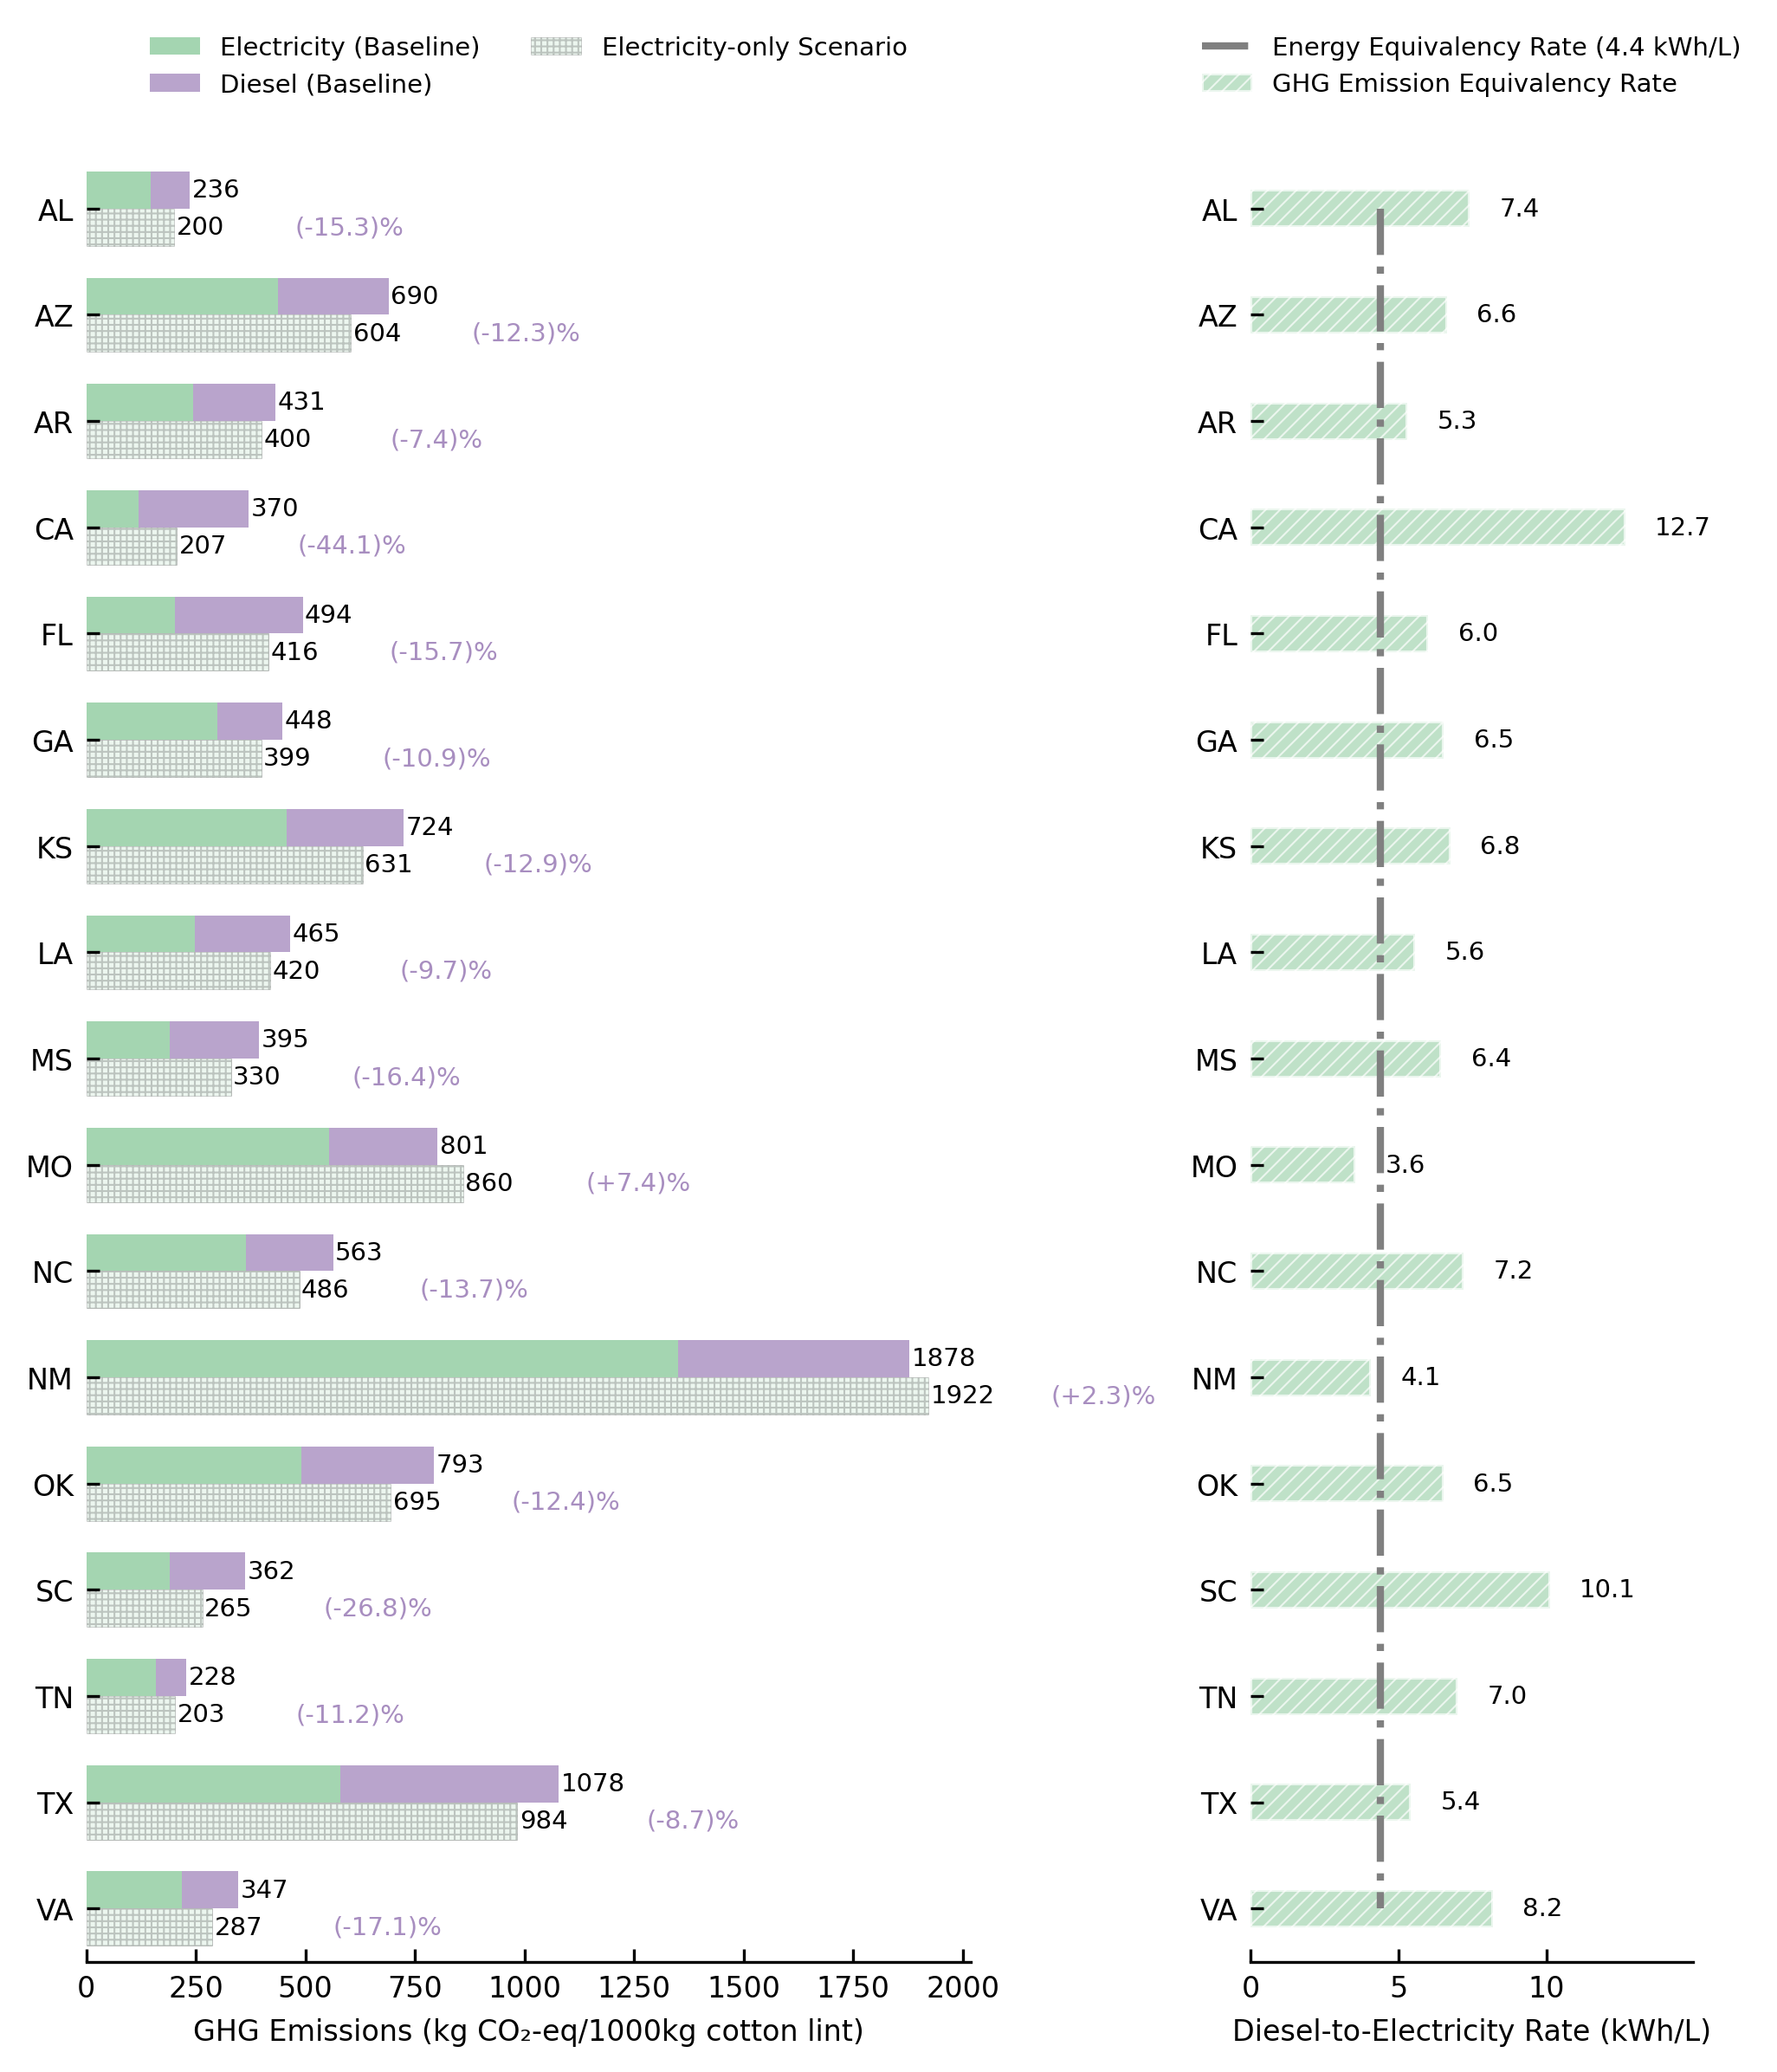

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.read_excel('../results/processed_data and results/Energy_Analysis_Summary.xlsx')
state_ef = pd.read_excel('../data/raw_cotton_data/state_electricity_emission_factors.xlsx')
data = data.merge(state_ef, on='State', how='left')

df = data
# Constant diesel EF
EF_diesel = 3.2  # kg CO2-eq/L  data for year 2025 from GREET model

# Shared legend font size for both panels
LEGEND_FS = 7

# Diesel/electricity from Energy_Analysis_Summary.xlsx are already lint-
# allocated (0.824) upstream in state_EnergyChemicals.ipynb; do not scale again.
print(df)
df['GHG_Electricity'] = df['Electricity (kWh/1000kg)'] * df['State-specific EF (kg CO2-eq/kWh)']
df['GHG_Diesel'] = df['Diesel (L/1000kg)'] * EF_diesel
df['GHG_Baseline'] = df['GHG_Electricity'] + df['GHG_Diesel']

# Pro-Electricity A: Uniform conversion, state-specific EF
conversion_A = 4.4
df['Electricity_A'] = df['Electricity (kWh/1000kg)'] + df['Diesel (L/1000kg)'] * conversion_A
df['GHG_A'] = df['Electricity_A'] * df['State-specific EF (kg CO2-eq/kWh)']

# Pro-Electricity B: State-specific conversion + EF (computed but not plotted)
df['Electricity_B'] = df['Electricity (kWh/1000kg)'] - df['Diesel (L/1000kg)'] * df['Current Rate']
df['GHG_B'] = df['Electricity_B'] * df['State-specific EF (kg CO2-eq/kWh)']

# COMBINED PLOTTING - Two subplots, each with its own y-axis
y = np.arange(len(df))
height = 0.35
offset = height / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.92, 8), sharey=False, gridspec_kw={'width_ratios': [2, 1]})

# LEFT PLOT: GHG Emissions
ax1.barh(y - offset, df['GHG_Electricity'], height, label='Electricity (Baseline)', color='#A4D5B1')
ax1.barh(y - offset, df['GHG_Diesel'], height, left=df['GHG_Electricity'], label='Diesel (Baseline)', color='#A88EC0', alpha=0.8)

# Scenario A
ax1.barh(y + offset, df['GHG_A'], height, label='Electricity-only Scenario', alpha=0.2, color='#A4D5B1', hatch='+++++++', edgecolor='k', linewidth=0.2)

# Labels for left plot
ax1.set_xlabel('GHG Emissions (kg CO₂-eq/1000kg cotton lint)')
ax1.set_yticks(y)
ax1.set_yticklabels(df['State'])
ax1.legend(frameon=False, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2, fontsize=LEGEND_FS)

# Annotate values for left plot
for i in y:
    ax1.text(df['GHG_Baseline'][i] + 5, i - offset, f"{df['GHG_Baseline'][i]:.0f}", va='center', fontsize=7)
    ax1.text(df['GHG_A'][i] + 5, i + offset, f"{df['GHG_A'][i]:.0f}", va='center', fontsize=7)

# Annotate percentage change for Scenario A
for i in y:
    ghg_base = df['GHG_Baseline'][i]
    ghg_a = df['GHG_A'][i]
    change_a = 100 * (ghg_a - ghg_base) / ghg_base
    ax1.text(ghg_a + 400, i + offset, f"({change_a:+.1f})%", va='center', ha='center', color='#A88EC0', fontsize=7)

# Remove spines for left plot
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# RIGHT PLOT: Conversion Rates
line_colors = ['#A88EC0', '#A4D5B1', 'grey']
line_styles = ['--', '-.', '-.']

# GHG Emission Equivalency Rate (bar plot)
if 'State-specific EF (kg CO2-eq/kWh)' in df.columns:
    ghg_reduction_rate = 3.2 / df['State-specific EF (kg CO2-eq/kWh)']

    ax2.barh(y, ghg_reduction_rate, height,
             color=line_colors[1], hatch='//////', edgecolor='white', alpha=0.7,
             label='GHG Emission Equivalency Rate')

    # Annotate bars just past their ends
    for i in y:
        value = ghg_reduction_rate.iloc[i]
        ax2.text(value + 1, i, f'{value:.1f}',
                 va='center', ha='left', fontsize=7, color='k')

# Energy Equivalency Rate (constant line, in the legend)
total_energy = df['Electricity (kWh/1000kg)'] * 0.0 + (4.4)
ax2.plot(total_energy, y,
         color=line_colors[2], linewidth=2, linestyle=line_styles[2], markersize=4, zorder=3,
         label='Energy Equivalency Rate (4.4 kWh/L)')

# Labels and own y-axis for right plot
ax2.set_xlabel('Diesel-to-Electricity Rate (kWh/L)', fontsize=8)
ax2.set_xlim(0, ghg_reduction_rate.max() * 1.18)
ax2.set_yticks(y)
ax2.set_yticklabels(df['State'])
ax2.tick_params(left=True)

# Remove spines for right plot
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.legend(frameon=False, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=1, fontsize=LEGEND_FS)

# Set y limits and invert BOTH axes (no longer linked)
ax1.set_ylim(-0.5, len(df) - 0.5)
ax2.set_ylim(-0.5, len(df) - 0.5)
ax1.invert_yaxis()
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/ghg_state/combined_state_level_analysis.tiff', dpi=300, bbox_inches='tight')
plt.show()